# Datos desbalanceados

El **desbalanceo de datos** (o el problema de **clases desequilibradas**) es una situación común en el Aprendizaje Automático (*Machine Learning*) donde existe una **proporción desigual** entre las clases en un conjunto de datos.

Este fenómeno se refiere a cuando los datos de una clase son significativamente **menos representativos** que los datos de otra clase en un conjunto dado.

### Impacto en la Ciencia de Datos

El desbalanceo de datos es un problema crítico porque puede dificultar el entrenamiento de un modelo de clasificación preciso. Cuando un conjunto de datos está desequilibrado, el algoritmo tiende a **favorecer a la clase más representativa** (la mayoritaria).

Consecuentemente, el modelo puede no ser capaz de reconocer adecuadamente los casos de la **clase minoritaria**.

**Ejemplo Práctico:**

Si un conjunto de datos tiene 1,000 ejemplos, de los cuales 900 pertenecen a la Clase A y solo 100 a la Clase B, el modelo podría tener dificultades para aprender correctamente la Clase B debido a la escasez de ejemplos representativos. Esto puede resultar en una **clasificación sesgada** y un bajo rendimiento en la detección de la clase minoritaria.

Este problema se observa frecuentemente en dominios donde los eventos de interés son raros, como la **detección de fraude** (donde hay muchas transacciones normales y pocas fraudulentas) o en el área de **salud** (donde hay muchos pacientes "negativos" y pocos casos "positivos" de una enfermedad).

### Contexto y Soluciones

El manejo de datos desbalanceados es un factor importante a considerar en el proceso de optimización del modelo.

El desequilibrio de clases puede ser abordado mediante técnicas de *Feature Engineering* (Ingeniería de Características). Algunas de las técnicas comunes para manejar datos desbalanceados incluyen:

*   **Submuestreo** (*Undersampling*): Reducir la clase mayoritaria.
*   **Sobremuestreo** (*Oversampling*): Aumentar la cantidad de datos sintéticos de la clase minoritaria, por ejemplo, utilizando **SMOTE** (*Synthetic Minority Over-Sampling Technique*).
*   **Ajuste de Parámetros del modelo:** Utilizar métodos como la **penalización** de la clase mayoritaria (a menudo a través de un parámetro como `class_weight="balanced"`) para intentar equilibrar la importancia de las clases durante el entrenamiento.
*   **Métodos de Conjunto** (*Ensemble*): Emplear técnicas que utilicen clasificadores con balanceo.

La librería **`imbalanced-learn` (`imblearn`)** en Python es comúnmente utilizada para implementar estas estrategias.

## Métricas

La métrica que se utiliza para evaluar y **mejorar el rendimiento** de los modelos que trabajan con **datos desbalanceados** no es una sola, sino un conjunto de métricas basadas en la **Matriz de Confusión** (Confusion Matrix), ya que la métrica de *Accuracy* (exactitud) es insuficiente y engañosa en estos contextos,.

Las métricas clave que mejoran la evaluación de los datos desbalanceados son:

### 1. Recall (Exhaustividad o Sensibilidad)

El *Recall* es quizás la métrica más importante cuando se trabaja con la clase minoritaria, ya que cuantifica qué tan bien el modelo es capaz de **detectar esa clase**.

*   En escenarios donde es fundamental encontrar todos los casos positivos (por ejemplo, detectar fraude o una enfermedad), el objetivo principal de la optimización del modelo es maximizar el *Recall*,.
*   El modelo debe evitar los **Falsos Negativos** (casos positivos reales que fueron clasificados erróneamente como negativos).
*   Las estrategias de balanceo de datos (como el sobremuestreo) buscan específicamente **aumentar el *Recall*** de la clase minoritaria, ya que este valor a menudo es bajo en el modelo inicial sin modificar,.

### 2. Precisión (Precision)

La *Precisión* define cuán confiable es el modelo cuando responde que un punto pertenece a una clase específica.

*   Se calcula como la fracción de predicciones positivas que fueron realmente correctas.
*   Al aplicar técnicas de balanceo, es común que la *Precisión* de la clase minoritaria disminuya mientras que el *Recall* aumenta (es decir, se obtienen más Falsos Positivos). La meta es encontrar un equilibrio aceptable entre ambos.

### 3. Puntuación F1 (F1 Score)

La Puntuación F1 es la **media armónica** de la precisión y el *Recall*, y proporciona una medida única que balancea ambos valores,.

*   A diferencia de la exactitud (*Accuracy*), que puede ser artificialmente alta en conjuntos desequilibrados, la Puntuación F1 de la clase minoritaria penaliza severamente el bajo *Recall*.
*   Si el *Recall* de la clase minoritaria es cero, la Puntuación F1 también será cero, lo que demuestra claramente el fallo del modelo en manejar la clase menos representada.

### 4. Área Bajo la Curva (AUC - Area Under the Curve)

La métrica de **AUC (Área Bajo la Curva)**, basada en la curva ROC (Receiver Operating Characteristic), es una medida recomendada que es **mucho mejor que la exactitud** (*Accuracy*) para cuantificar el rendimiento predictivo en problemas de clasificación desbalanceada.

*   El AUC mide la capacidad del clasificador para distinguir entre las clases.
*   A diferencia de *Accuracy*, si un modelo predice las clases de forma aleatoria, el AUC será de 0.5, independientemente del desbalanceo, lo que lo convierte en un indicador robusto de si el modelo es mejor que la pura casualidad.

Accuracy: 0.9833
Precision: 0.9310
Recall: 0.9000
F1 Score: 0.9153


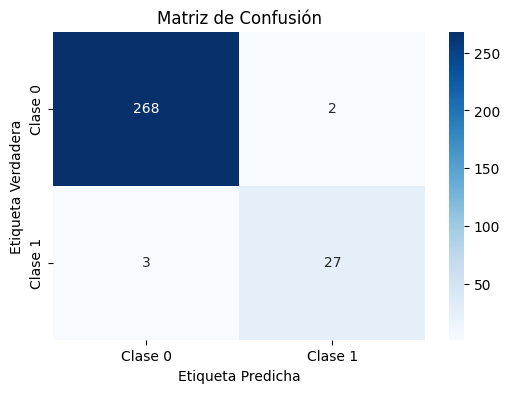

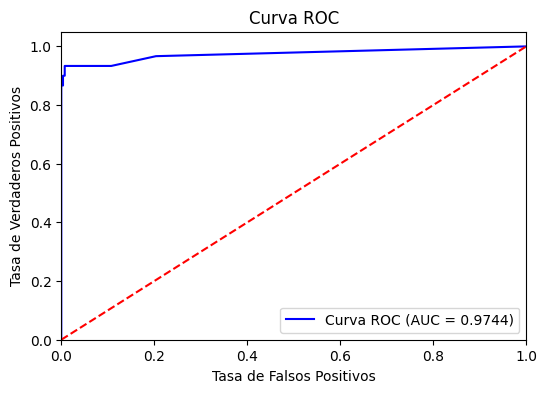

In [ ]:
# genera un ejemplo completo y autocontenido para demostrar datos desbalanceados 
# y las metricas de evaluación mencionadas en este cuaderno.
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns   

# Generar un conjunto de datos desbalanceado
X, y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=10,
                           n_clusters_per_class=1, weights=[0.9, 0.1], flip_y=0, random_state=42)

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Entrenar un clasificador
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Hacer predicciones
y_pred = clf.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar resultados
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.title('Matriz de Confusión')
plt.show()


# genera un grafico para La métrica de AUC (Área Bajo la Curva), basada en la curva ROC (Receiver Operating Characteristic)
from sklearn.metrics import roc_curve, auc

# Obtener probabilidades de predicción
y_prob = clf.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.9995
Precision: 0.9573
Recall: 0.7568
F1 Score: 0.8453


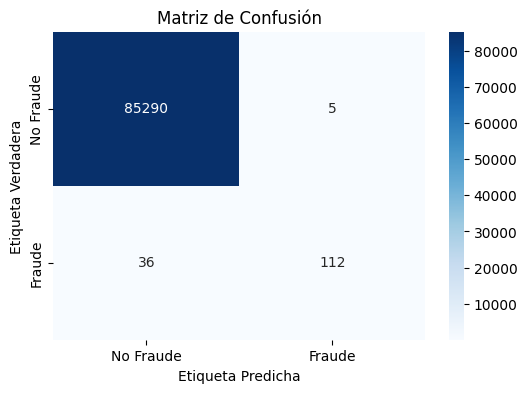

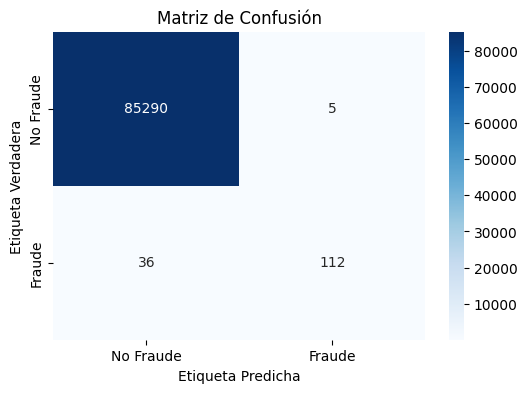

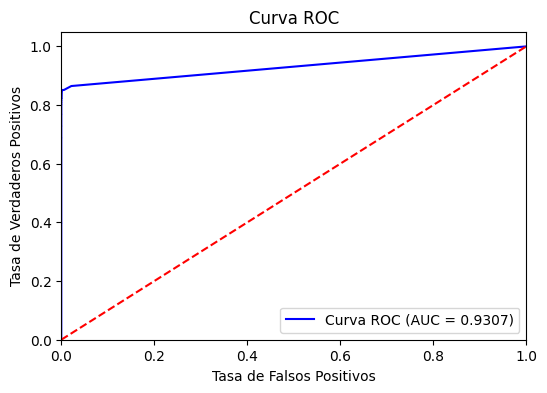

In [5]:
# Fraude en tarjetas de credito
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# genera un ejemplo completo y autocontenido para demostrar datos desbalanceados 
# y las metricas de evaluación mencionadas en este cuaderno. Utiliza un dataset de ejemplo diferente con datos reales no sinteticos
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar un conjunto de datos real (por ejemplo, el conjunto de datos de fraude con tarjetas de crédito)
url = "../data/creditcard.csv"
data = pd.read_csv(url)

# Seleccionar características y etiqueta
X = data.drop('Class', axis=1)
y = data['Class']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Entrenar un clasificador
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Hacer predicciones
y_pred = clf.predict(X_test)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar resultados
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.title('Matriz de Confusión')
plt.show()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.title('Matriz de Confusión')
plt.show()

# genera un grafico para La métrica de AUC (Área Bajo la Curva), basada en la curva ROC (Receiver Operating Characteristic)
from sklearn.metrics import roc_curve, auc

# Obtener probabilidades de predicción
y_prob = clf.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

